# Tarea 3
### Francisco Javier Villarroel Herrera

In [1]:
#Importamos todas las librerias a trabajar

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy
import linearmodels.panel as lmp
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from stepmix.stepmix import StepMix

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

**Diccionario de Variables**

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- area: urbana=1, rural=0
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

## 1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcétera). Identifique los tipos de datos que se encuentran en la base, realice estadísticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
#Cargamos el dataframe, a ejecutarse desde una subcarpeta de 2025.
df = pd.read_csv('../../../data/junaeb3.csv')
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [3]:
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


In [4]:
df.dtypes

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
dtype: object

**Estadística Descriptiva**

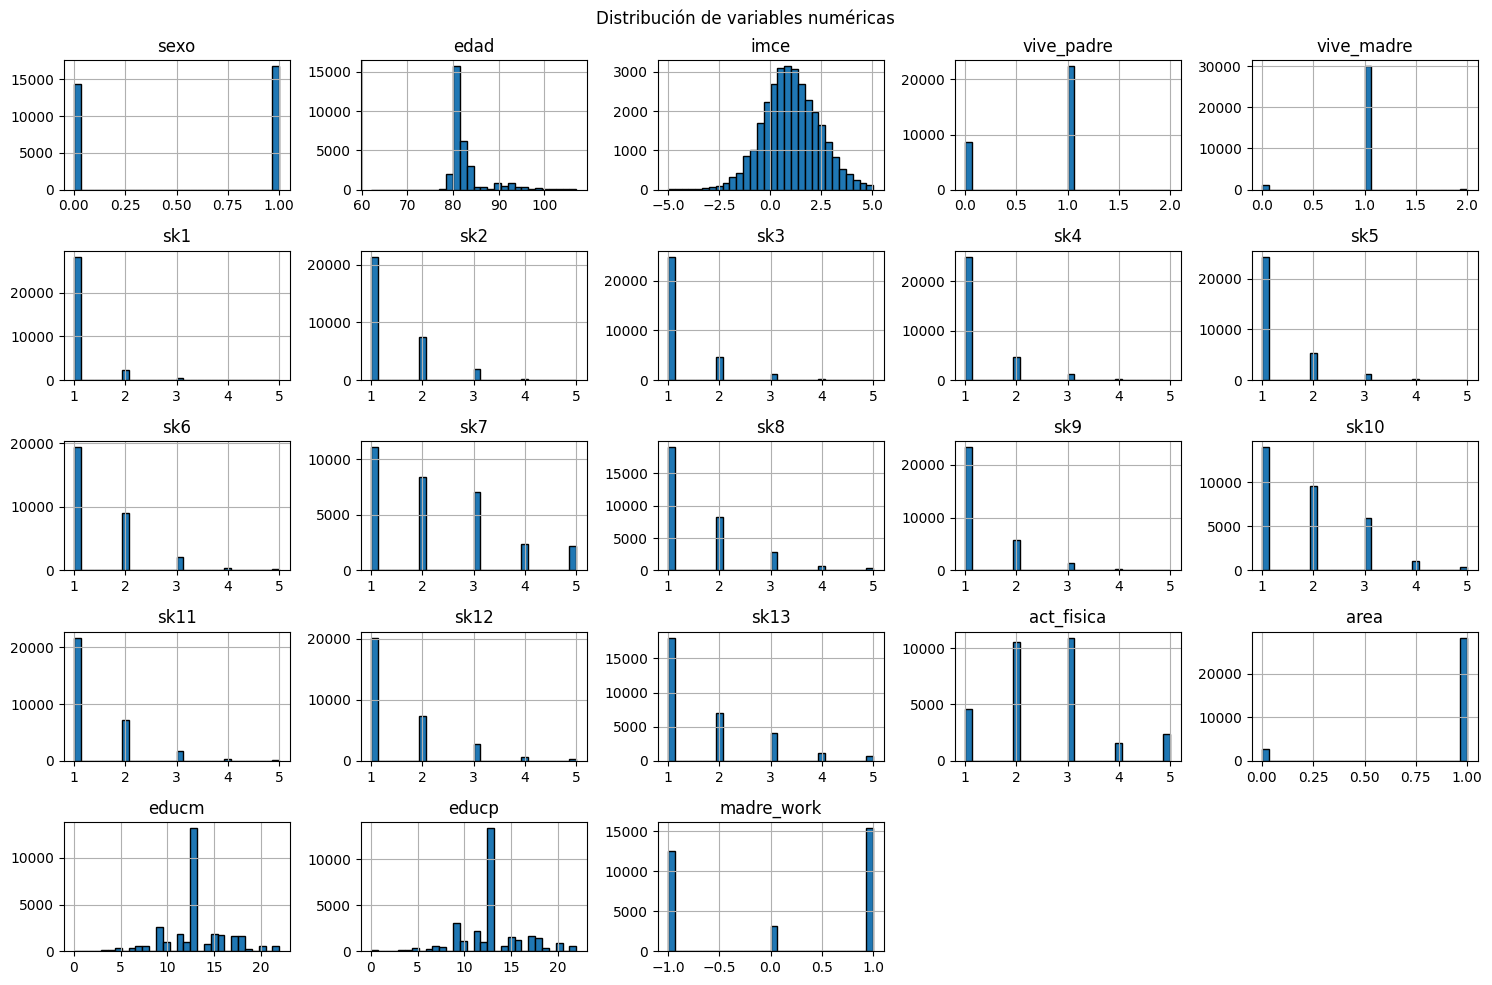

In [5]:
# Seleccionar solo columnas numéricas
numericas = df.select_dtypes(include='number')

# Histograma para cada variable
numericas.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()

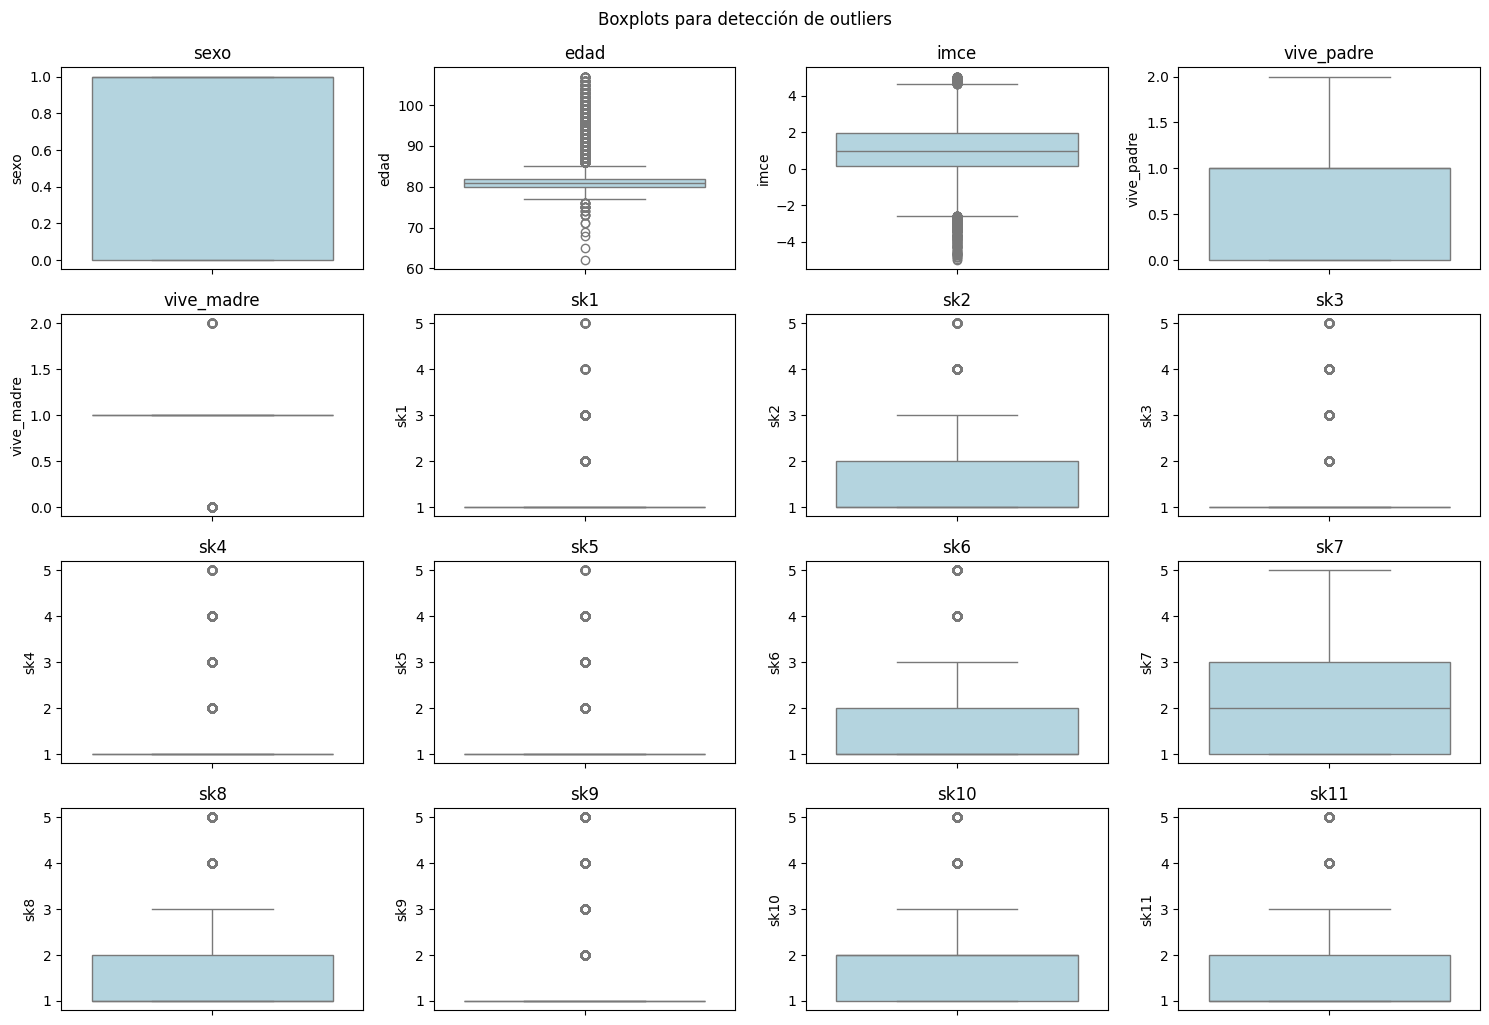

In [6]:
# Boxplot de cada variable numérica
plt.figure(figsize=(15, 10))
for i, col in enumerate(numericas.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
    plt.tight_layout()
    if i==16:
        break
plt.suptitle('Boxplots para detección de outliers', y=1.02)
plt.show()

Tanto en los histogramas, como en los gráficos de caja, no se observo ninguna variable anormal dentro de la data, por lo que no se realizarán ajustes adicional al dataframe trabajado.

Se obtuvo la Matriz de correlación

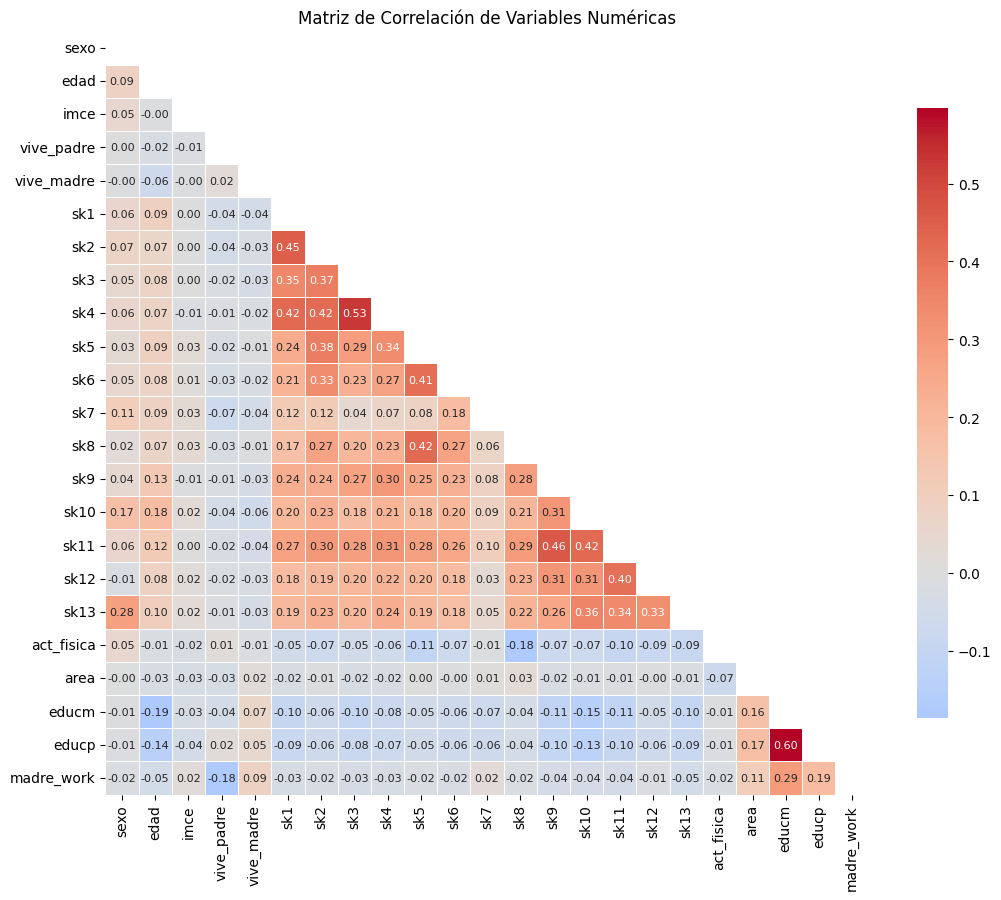

In [7]:
# Matriz de correlación
corr = numericas.corr()

# Crea la máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Establece tamaño del gráfico y el color
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Heatmap
sns.heatmap(corr, annot=True, mask=mask, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

Finalmente nos deshacemos de los NaN restantes.

In [8]:
#Limpiamos los datos faltantes.
df.dropna(inplace=True)
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


## 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el número óptimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representadas en el mismo sentido lógico. Si una característica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [9]:
df1 = df[['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6','sk7', 'sk8', 'sk9','sk10', 'sk11', 'sk12','sk13']]

In [10]:
# Crear objeto de análisis factorial y realizar análisis factorial.
fa = FactorAnalyzer(rotation='oblimin').fit(df1)

In [11]:
# Matriz de cargas factoriales.
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.026180, 0.582127, -0.018381],
       [0.003822, 0.488151, 0.229967],
       [0.021377, 0.634979, -0.021518],
       [0.007279, 0.742976, -0.014923],
       [-0.034914, 0.026604, 0.759664],
       [0.055571, 0.069985, 0.478603],
       [0.038456, 0.032268, 0.134857],
       [0.214279, -0.084792, 0.471477],
       [0.500340, 0.073356, 0.052826],
       [0.608174, -0.024014, -0.026428],
       [0.702788, 0.033519, 0.008785],
       [0.571171, -0.034542, 0.001340],
       [0.508882, 0.030916, -0.010975]])

Excluimos sk7 del análisis debido a que su relación con todos los factores es muy baja.

In [12]:
df1 = df[['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8', 'sk9','sk10', 'sk11', 'sk12','sk13']]

In [13]:
# Crear objeto de análisis factorial y realizar análisis factorial.
fa = FactorAnalyzer(rotation='oblimin').fit(df1)

In [14]:
# Matriz de cargas factoriales.
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.025091, 0.592769, -0.036490],
       [0.014132, 0.504176, 0.201440],
       [0.015141, 0.633897, -0.014981],
       [0.001552, 0.742733, -0.011935],
       [-0.030999, 0.020518, 0.804761],
       [0.081477, 0.098873, 0.419382],
       [0.231480, -0.072300, 0.454024],
       [0.502530, 0.074356, 0.049459],
       [0.610043, -0.023017, -0.033028],
       [0.704005, 0.033629, 0.005354],
       [0.570888, -0.038834, 0.007890],
       [0.508570, 0.028714, -0.008627]])

Factores obtenidos:

- Habilidades socioemocionales: sk1 + sk2 + sk3 + sk4     
- Habilidades sociales: sk5 + sk6 + sk8
- Habilidades cognitivas: sk9 + sk10 + sk11 + sk12 + sk13

In [15]:
# Calculamos los valores propios.
fa.get_eigenvalues()

(array([4.003739, 1.347633, 1.089935, 0.802648, 0.743580, 0.706589,
        0.691043, 0.610450, 0.531272, 0.519068, 0.491722, 0.462321]),
 array([3.392029, 0.739425, 0.534958, 0.139459, 0.078895, 0.040789,
        -0.022950, -0.044788, -0.059629, -0.082529, -0.108439, -0.180479]))

In [16]:
# Calculamos las comunalidades.
fa.get_communalities()

array([0.353336, 0.294971, 0.402279, 0.551797, 0.649022, 0.192296,
       0.264948, 0.260512, 0.373773, 0.496782, 0.327484, 0.259543])

Criterio del valor propio, para obtener número de factores.

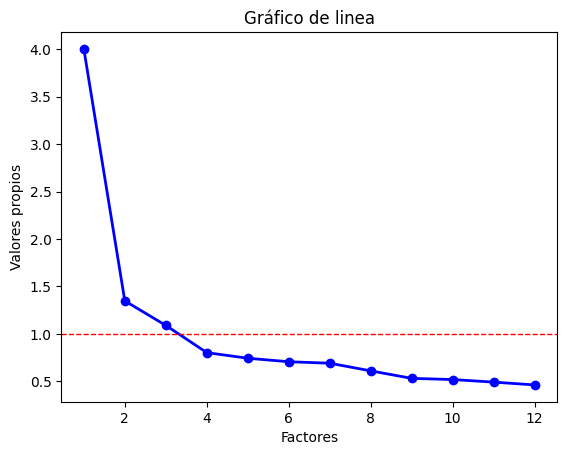

In [17]:
values = np.arange(1,13)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1)
plt.title('Gráfico de linea')
plt.xlabel('Factores')
plt.ylabel('Valores propios')
plt.show()

Calcular información de varianza de factores.

In [18]:
fa.get_factor_variance()

(array([1.767112, 1.583991, 1.075637]),
 array([0.147259, 0.131999, 0.089636]),
 array([0.147259, 0.279259, 0.368895]))

Comparamos con Semopy

In [19]:
print(semopy.efa.explore_cfa_model(df1, pval=0.05))

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



Se realizó un Análisis Factorial Exploratorio (EFA) sobre las variables sk1 a sk13 (todas con el mismo sentido lógico) con el objetivo de identificar dimensiones asociadas al desarrollo infantil.

Durante el proceso, se detectó que la variable sk7 no presentaba cargas significativas en ninguno de los factores, por lo que fue excluida del análisis por su baja capacidad informativa. El análisis factorial, aplicado a las 12 variables restantes, reveló una solución de tres factores como la más adecuada, según el criterio del valor propio mayor a 1 (Kaiser-Guttman). Estos tres factores explicaron en conjunto aproximadamente un 37% de la varianza total, con varianzas explicadas de 14.7%, 13.2% y 9.0%, respectivamente.

La inspección de la matriz de cargas factoriales permitió interpretar los factores de la siguiente manera:

Factor 1 (Habilidades socioemocionales): sk1 a sk4 (afecto a padres y pares, expresión emocional).

Factor 2 (Habilidades sociales): sk5, sk6 y sk8 (juego con otros, compartir, y juegos grupales).

Factor 3 (Habilidades cognitivas): sk9 a sk13 (interés por el entorno, libros, juegos de construcción, y expresiones artísticas).

Finalmente, se intentó confirmar esta estructura mediante un modelo de medición en semopy, pero los resultados mostraron problemas de solapamiento excesivo entre ítems (mismos indicadores apareciendo en varios factores), lo cual apoyó la decisión de mantener la solución obtenida vía EFA como la representación más clara y teóricamente coherente del comportamiento de los niños.

## 3. Con los resultados de la Pregunta 2, gráficamente indique si existen diferencias significativas en la distribución de los factores usando las siguientes variables para caracterizar: sexo, área, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opción 'hue' para agregar variables de caracterización). ¿Qué puede concluir de los resultados?

In [20]:
# DataFrame con las variables del análisis factorial.
factores = fa.transform(df1)

# Convertir las puntuaciones de los factores en un DataFrame.
factores_df = pd.DataFrame(factores, columns=["Factor 1", "Factor 2", "Factor 3"])

# Agregar estos factores a un DataFrame para graficar.
df_g = df.copy()
df_g['Factor 1'] = factores_df['Factor 1']
df_g['Factor 2'] = factores_df['Factor 2']
df_g['Factor 3'] = factores_df['Factor 3']

Obtenemos los gráficos para su análisis.

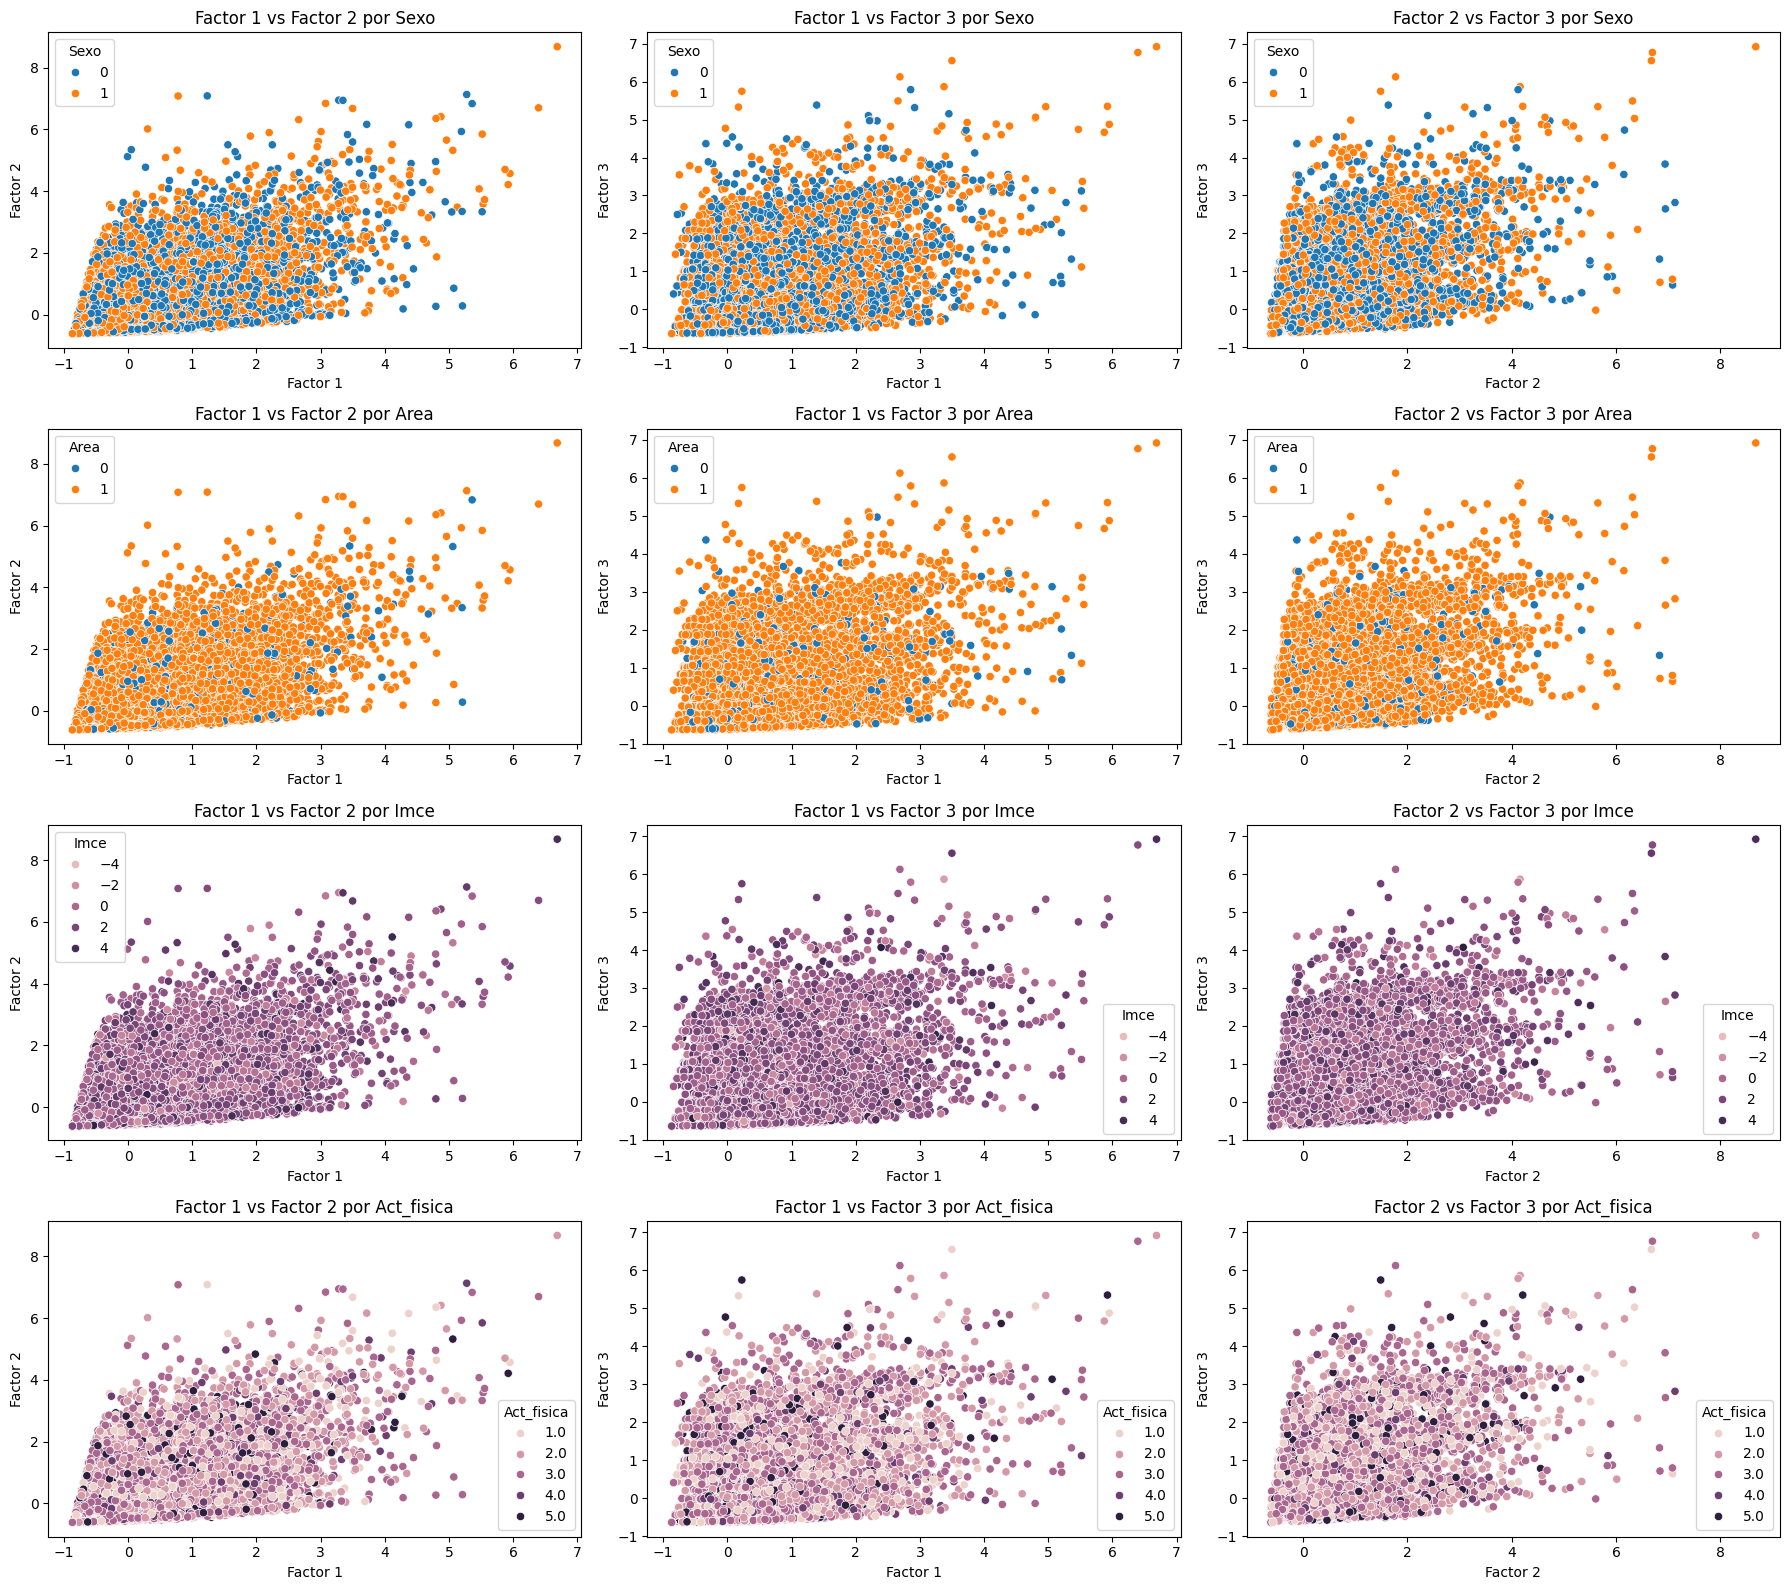

In [21]:
# Lista de las variables de caracterización
Variables = ['sexo', 'area', 'imce', 'act_fisica']

# Definir el número de filas y columnas para los subgráficos
# En este caso, asumimos 4 variables y 3 combinaciones de factores por variable
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))

# Aplanar la matriz de ejes para facilitar la iteración
axes = axes.flatten()

# Iterar sobre las variables y graficar en los subgráficos
for idx, var in enumerate(Variables):
    # Graficar Factor 1 vs Factor 2, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_g, x='Factor 1', y='Factor 2', hue=var, ax=axes[idx*3])
    axes[idx*3].set_title(f'Factor 1 vs Factor 2 por {var.capitalize()}')
    axes[idx*3].set_xlabel('Factor 1')
    axes[idx*3].set_ylabel('Factor 2')
    axes[idx*3].legend(title=var.capitalize())

    # Graficar Factor 1 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_g, x='Factor 1', y='Factor 3', hue=var, ax=axes[idx*3 + 1])
    axes[idx*3 + 1].set_title(f'Factor 1 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 1].set_xlabel('Factor 1')
    axes[idx*3 + 1].set_ylabel('Factor 3')
    axes[idx*3 + 1].legend(title=var.capitalize())

    # Graficar Factor 2 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_g, x='Factor 2', y='Factor 3', hue=var, ax=axes[idx*3 + 2])
    axes[idx*3 + 2].set_title(f'Factor 2 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 2].set_xlabel('Factor 2')
    axes[idx*3 + 2].set_ylabel('Factor 3')
    axes[idx*3 + 2].legend(title=var.capitalize())

# Ajustar el layout para que los gráficos no se solapen, y mostrar.
plt.tight_layout()
plt.show()

A partir de las puntuaciones factoriales obtenidas en la Pregunta 2, se exploró gráficamente si existían diferencias en la distribución de los factores latentes (habilidades socioemocionales, sociales y cognitivas) en función de cuatro variables de caracterización: sexo, área geográfica, IMCE y actividad física. Para ello, se utilizaron diagramas de dispersión en pares de factores, aplicando el parámetro hue para representar visualmente la influencia de cada variable categórica o continua.

Los resultados gráficos no evidencian patrones claros ni agrupamientos definidos que sugieran diferencias sistemáticas en los factores en función de las variables analizadas. En todas las combinaciones de pares factoriales, la distribución de los puntos se muestra ampliamente dispersa, y las categorías (como sexo o área) no generan clústeres visuales distinguibles. De igual forma, para las variables continuas (IMCE y actividad física), no se observan gradientes evidentes ni relaciones lineales notorias.

En conclusión, los factores parecen distribuirse de forma relativamente homogénea respecto a las variables de caracterización consideradas. Esto sugiere que, al menos visualmente, no existen diferencias significativas en las habilidades socioemocionales, sociales o cognitivas de los niños según sexo, zona de residencia, IMCE o frecuencia de actividad física.

## 4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto común entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlación entre factores (loadings). 

In [22]:
mod = """
# measurement model

eta1 =~ sk1 + sk2 + sk3 + sk4               # Habilidades socioemocionales
eta2 =~ sk5 + sk6 + sk8                     # Habilidades sociales
eta3 =~ sk9 + sk10 + sk11 + sk12 + sk13     # Habilidades cognitivas
    """

model = semopy.Model(mod)
out=model.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.877 1.646 1.846 1.020 1.158 1.348 1.248 1.097 1.274 0.049 0.057 0.051 0.161 0.091 0.152 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [23]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk1,~,eta1,1.000000,0.582652,-,-,-
1,sk2,~,eta1,1.876642,0.644548,0.023793,78.87212,0.0
2,sk3,~,eta1,1.646084,0.631816,0.021121,77.934883,0.0
3,sk4,~,eta1,1.845637,0.715782,0.022169,83.253688,0.0
4,sk5,~,eta2,1.000000,0.718118,-,-,-
5,sk6,~,eta2,1.019985,0.556582,0.01433,71.178266,0.0
6,sk8,~,eta2,1.158490,0.560988,0.016193,71.542093,0.0
7,sk9,~,eta3,1.000000,0.594425,-,-,-
8,sk10,~,eta3,1.348296,0.562596,0.01854,72.725071,0.0
9,sk11,~,eta3,1.247906,0.736003,0.014736,84.684717,0.0


In [24]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


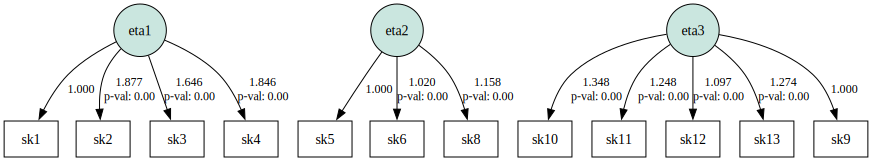

In [25]:
semopy.semplot(model, "model.png")

A partir de la estructura identificada en el Análisis Factorial Exploratorio (EFA), se formuló un modelo de Análisis Factorial Confirmatorio (CFA) en el cual cada variable se asocia exclusivamente a un único factor. El modelo especificado agrupa las variables en tres factores latentes con significados conceptuales claros: (1) habilidades socioemocionales (sk1–sk4), (2) habilidades sociales (sk5, sk6, sk8) y (3) habilidades cognitivas (sk9–sk13). Esta estructura refleja una organización lógica y coherente de las competencias infantiles evaluadas.

Siguiendo esto, se calculo el CFI y el TLI miden qué tan bien se ajusta el modelo a los datos, siendo mejores mientras más cerca estén de 1 (mayor a 0.90 es aceptable). El RMSEA evalúa el error de aproximación del modelo, valores por debajo de 0.06 indican buen ajuste.

Los resultados del CFA muestran que el modelo propuesto presenta un ajuste aceptable, con índices estándar de calidad del ajuste dentro de rangos recomendados: CFI = 0.948, TLI = 0.932 y RMSEA = 0.0526, indicando que el modelo representa adecuadamente los datos observados.

En cuanto a la importancia relativa de las variables dentro de cada factor, los loadings estandarizados fueron en general altos, lo que indica una fuerte asociación entre las variables y los factores que pretenden medir. Por ejemplo, dentro del factor de habilidades socioemocionales, las variables sk2, sk3, sk4 y sk5 presentan cargas superiores a 0.63, mientras que en habilidades cognitivas, como sk11 destacan por su fuerte contribución (≥ 0.73).

Además, las correlaciones entre factores también fueron moderadas y estadísticamente significativas. Se observó una correlación de 0.65 entre habilidades socioemocionales y sociales, lo que refleja una relación lógica entre ambos dominios. La correlación entre habilidades socioemocionales y cognitivas fue de 0.60, y entre sociales y cognitivas de 0.58, indicando que si bien los factores están relacionados, cada uno mide dimensiones distintas del desarrollo infantil.

Por lo tanto, el CFA respalda empíricamente la estructura de tres factores latentes propuesta, confirmando que las variables observadas se agrupan coherentemente en torno a conceptos diferenciados, con buena calidad de ajuste y asociaciones fuertes y consistentes entre indicadores y constructos latentes.

## 5. Estime un modelo de clases latentes usando imce via StepMix. Determine el número óptimo de clases (clusters) y muestre las diferencias entre clusters gráficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.39s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.68s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:16<00:00, 16.38s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.30s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.85s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


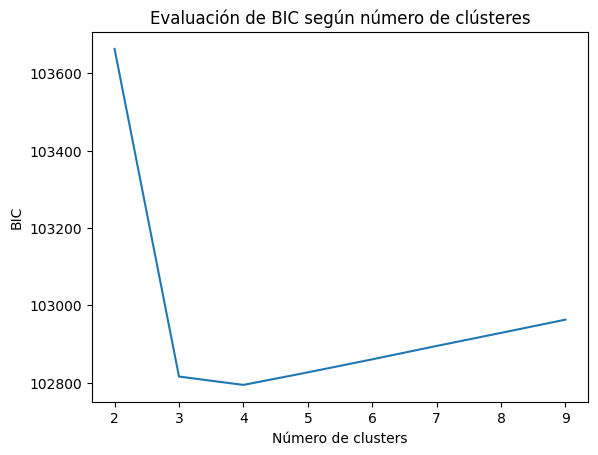

In [26]:
from stepmix.stepmix import StepMix

# Numero óptimo de clusters
K = range(2, 10)
fits = []
BIC = []

df1=df[['imce']]

for k in K:
    # Entrenar el modelo para el valor actual de k.
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df1)
    
    # Añadir el modelo a los ajustes.
    fits.append(model)
    
    # Añadir la puntuación de la silueta a las puntuaciones
    BIC.append(model.sabic(df1))

sns.lineplot(x = K, y = BIC)
plt.title('Evaluación de BIC según número de clústeres')
plt.xlabel('Número de clusters')
plt.ylabel('BIC')
plt.show()

In [27]:
# StepMix con gaussian

model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(df1)
df1['pred']=model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.91s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


In [28]:
df1.groupby(['pred'])[['imce']].mean()

,imce
pred,
0,-2.745749
1,2.865709
2,0.541296


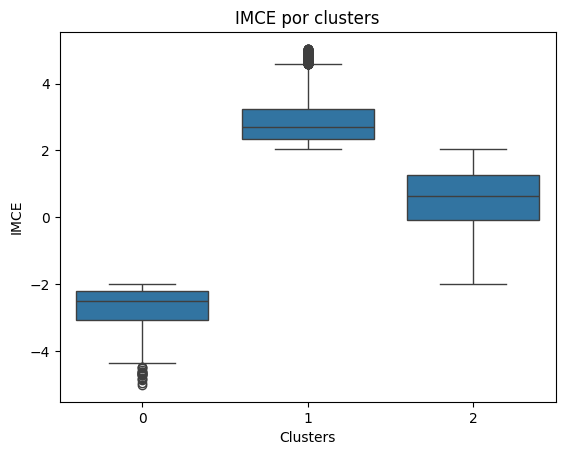

In [29]:
sns.boxplot(
    x='pred',
    y='imce',
    data=df1,
)
plt.title('IMCE por clusters')
plt.xlabel('Clusters')
plt.ylabel('IMCE')
plt.show()

Para identificar subgrupos latentes de estudiantes en función de su IMCE, se estimó un modelo de clases latentes utilizando la librería StepMix, considerando una distribución gaussiana para la variable continua.

Primero, se determinó el número óptimo de clases (clusters) evaluando modelos con entre 2 y 9 clases, usando el BIC ajustado (sabic) como criterio de selección. El gráfico de BIC mostró una clara mejora significativa al pasar de 2 a 3 clases, con una estabilización posterior en 4 clases y un aumento progresivo desde 5 clases en adelante. Por tanto, se seleccionó 3 clases como la solución óptima, balanceando calidad de ajuste y parsimonia.

El modelo final estimado mostró tres clases bien diferenciadas en términos de su media de IMCE:

Clase 1 (2%): media de IMCE ≈ -1.95, correspondiente a bajo peso.

Clase 2 (27%): media de IMCE ≈ 2.41, correspondiente a sobrepeso u obesidad.

Clase 3 (71%): media de IMCE ≈ 0.60, correspondiente a un estado nutricional normal.

Estas clases no solo son numéricamente diferentes, sino que también presentan claras diferencias visuales al representarlas con un boxplot, donde se observa sin solapamiento entre las clases, lo que sugiere que el modelo ha logrado segmentar adecuadamente a los individuos en categorías distintas y significativas desde el punto de vista del estado nutricional.

El modelo de clases latentes permite identificar tres subgrupos homogéneos en IMCE, con una distribución esperable en la población escolar: una mayoría con IMCE normal (71%), una fracción considerable con sobrepeso (27%) y una minoría con bajo peso (2%).

## 6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Además utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teórico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CFI, RMSEA). ¿Qué puede concluir en base a sus resultados?

In [30]:
df_g = df_g.drop('sk7', axis=1)
numericas = df_g.select_dtypes(include='number')

Se obtiene nuevamente la matriz de correlación.

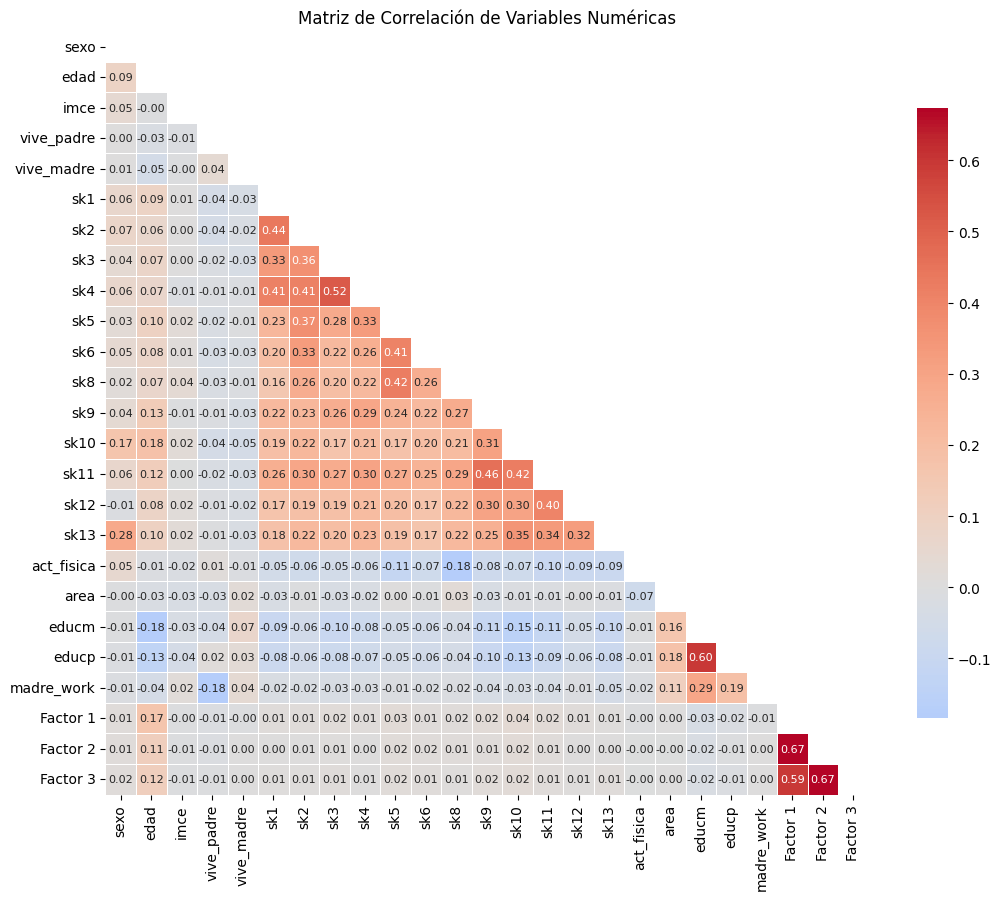

In [31]:
# Matriz de correlación
corr = numericas.corr()

# Crea la máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Establece tamaño del gráfico y el color
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Heatmap
sns.heatmap(corr, annot=True, mask=mask, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

Modelo SEM

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.311
Number of iterations: 82
Params: 1.877 1.646 1.846 1.019 1.158 1.359 1.239 1.093 1.273 -0.297 0.234 -0.015 -0.022 0.135 -0.004 -0.605 0.420 2.156 17.692 0.049 0.057 0.051 0.161 0.091 0.152 1.865 0.095 0.590 0.202 0.443 0.713 0.242 0.199 0.158 0.151 0.372 0.470 0.277
    lval  op        rval   Estimate  Std. Err     z-value   p-value
0   edad   ~        eta1  -0.605448  0.218064   -2.776472  0.005495
1   edad   ~        eta2   0.419831   0.12549    3.345539  0.000821
2   edad   ~        eta3   2.156018   0.11233   19.193635       0.0
3    sk1   ~        eta1   1.000000         -           -         -
4    sk2   ~        eta1   1.877363  0.023797    78.88982       0.0
5    sk3   ~        eta1   1.645839  0.021118   77.933563       0.0
6    sk4   ~        eta1   1.845945  0.022169   83.267962       0.0
7    sk5   ~        eta2   1.000000         -         

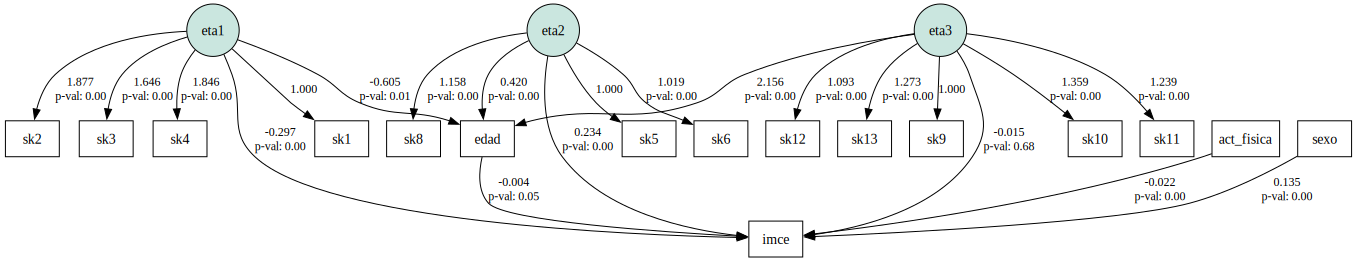

In [32]:
mod_cf = """
# measurement model

eta1 =~ sk1 + sk2 + sk3 + sk4               # Habilidades socioemocionales
eta2 =~ sk5 + sk6 + sk8                     # Habilidades sociales
eta3 =~ sk9 + sk10 + sk11 + sk12 + sk13     # Habilidades cognitivas

# Structural

# IMCE explicado por los factores latentes y variables clave
imce ~ eta1 + eta2 + eta3 + act_fisica + sexo + edad
edad ~ eta1 + eta2 + eta3
    """

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)

print(model_cfa.inspect())
semopy.semplot(model_cfa, "semmodel.png")

In [33]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,98,122,9228.691426,0.0,87030.643579,0.894939,0.89396,0.867992,0.89396,0.86921,0.056014,75.378456,390.731626,0.310772


Se implementó un modelo de ecuaciones estructurales (SEM) que integra factores latentes derivados de habilidades personales (socioemocionales, sociales y cognitivas) junto a variables observadas relevantes para explicar el índice de masa corporal estandarizado (IMCE) en escolares. La estructura del modelo se fundamentó tanto en criterios teóricos como empíricos: se incluyeron variables observadas como la actividad física, el sexo y la edad, dada su conocida relación con el estado nutricional infantil. Además, los factores latentes fueron definidos en base a agrupaciones consistentes de preguntas relacionados al desarrollo integral del niño, siguiendo principios teóricos del desarrollo infantil.

Una primera motivación para incluir la edad en el modelo no sólo como variable explicativa del IMCE, sino también como variable dependiente de los factores latentes, surge del hecho de que estas habilidades (socioemocionales, sociales y cognitivas) maduran y se desarrollan con la edad. Esto se confirmó empíricamente en el modelo, donde todos los factores latentes presentaron relaciones significativas con la edad, especialmente el factor cognitivo (eta3), con un coeficiente muy alto (2.15) y altamente significativo, lo que refleja una trayectoria de desarrollo esperada en la infancia. De este modo, la edad actúa tanto como indicador del desarrollo como posible moderador de sus efectos sobre el IMCE.

En cuanto a los efectos sobre el IMCE, los resultados indicaron que las habilidades socioemocionales (eta1) tienen un efecto negativo y significativo, lo cual puede interpretarse como que los niños con mayor autorregulación emocional y habilidades de autocontrol tienden a presentar un menor IMCE, probablemente porque son más capaces de mantener hábitos saludables, controlar impulsos alimentarios y participar en actividades físicas. De forma similar, la actividad física presentó un efecto negativo significativo sobre el IMCE, validando el efecto protector ampliamente reportado en la literatura.

El sexo mostró una relación positiva y altamente significativa con el IMCE, reflejando diferencias de género que pueden atribuirse a factores fisiológicos, conductuales o culturales en esta etapa del desarrollo. Por su parte, las habilidades sociales (eta2) mostraron un efecto positivo y significativo, lo cual puede parecer contraintuitivo. Sin embargo, este resultado podría reflejar contextos en los que la integración social se asocia con hábitos colectivos menos saludables, como compartir alimentos ultraprocesados o pasar más tiempo en actividades sedentarias grupales.

En contraste, el factor cognitivo (eta3) no mostró una relación significativa con el IMCE, lo que sugiere que el desarrollo cognitivo, si bien crece con la edad, no tiene un efecto directo apreciable sobre el estado nutricional cuando se controlan otros factores como la actividad física y la autorregulación emocional.

Desde el punto de vista del ajuste del modelo, los índices obtenidos fueron aceptables:

CFI = 0.895,

TLI = 0.869,

RMSEA = 0.056.
Aunque el CFI y el TLI están ligeramente por debajo del umbral clásico de 0.90, los valores indican un ajuste razonablemente bueno para un modelo con esta complejidad y con una muestra grande. El RMSEA, por su parte, está por debajo de 0.06, lo que respalda la validez del modelo.

## 7. Repita el análisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parámetros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?

In [34]:
df1 = df1.drop('imce', axis=1)
df2 = pd.concat([df, df1], axis=1)
df2

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,pred
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,2
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,2
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,2
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,1,1,2.0,1,13.0,13,-1,2
31051,1,79,2.57,1,1,1,1,2,2,1,...,3,2,1,4,3.0,1,18.0,19,0,1
31052,0,78,2.12,1,1,1,1,1,1,1,...,3,1,1,1,3.0,1,13.0,9,1,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,2,1,1,2,2.0,1,17.0,15,1,2


In [35]:
df_c1 = df2[df2['pred'] == 0]
df_c2 = df2[df2['pred'] == 1]
df_c3 = df2[df2['pred'] == 2]

In [36]:
df_c1 = df_c1.drop('pred', axis=1)
df_c2 = df_c2.drop('pred', axis=1)
df_c3 = df_c3.drop('pred', axis=1)

Clase 1

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.622
Number of iterations: 96
Params: 2.464 2.203 2.797 1.083 1.304 1.047 1.107 0.822 1.066 0.977 -0.394 -0.092 0.090 -0.084 -0.001 -5.519 1.337 1.498 20.725 0.028 0.048 0.047 0.153 0.093 0.226 0.469 0.081 0.654 0.217 0.350 0.764 0.242 0.199 0.136 0.164 0.409 0.535 0.278
    lval  op        rval   Estimate  Std. Err    z-value   p-value
0   edad   ~        eta1  -5.518761  3.386681  -1.629549  0.103197
1   edad   ~        eta2   1.336828  1.369448    0.97618  0.328975
2   edad   ~        eta3   1.497980  0.772714   1.938596  0.052551
3    sk1   ~        eta1   1.000000         -          -         -
4    sk2   ~        eta1   2.463637  0.289657   8.505349       0.0
5    sk3   ~        eta1   2.203039   0.26004    8.47192       0.0
6    sk4   ~        eta1   2.796742  0.303546   9.213566       0.0
7    sk5   ~        eta2   1.000000         -          -      

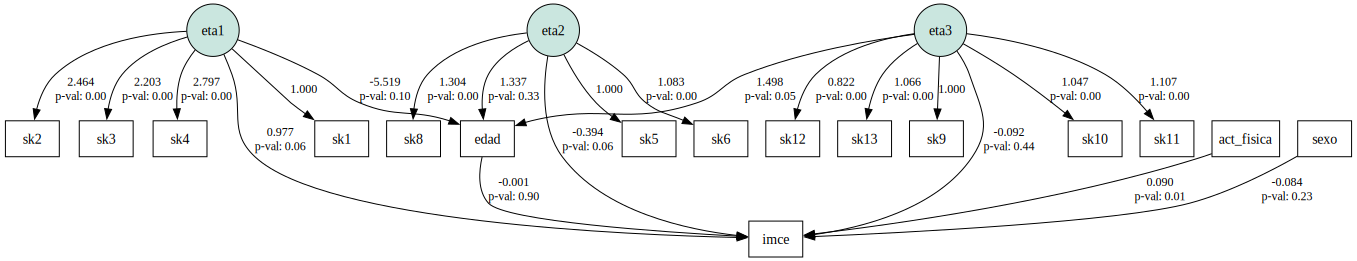

In [37]:
mod_cf = """
# measurement model

eta1 =~ sk1 + sk2 + sk3 + sk4               # Habilidades socioemocionales
eta2 =~ sk5 + sk6 + sk8                     # Habilidades sociales
eta3 =~ sk9 + sk10 + sk11 + sk12 + sk13     # Habilidades cognitivas

# Structural

# IMCE explicado por los factores latentes y variables clave
imce ~ eta1 + eta2 + eta3 + act_fisica + sexo + edad

#Explicación de los factores latentes por entorno socioeconómico
edad ~ eta1 + eta2 + eta3
    """

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df_c1);
print(out)

print(model_cfa.inspect())
semopy.semplot(model_cfa, "semmodel.png")

In [38]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,98,122,257.655685,2.220446e-16,1400.98047,0.87517,0.816089,0.77105,0.816089,0.844599,0.062806,74.755287,227.738194,0.622357


Clase 2

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.344
Number of iterations: 56
Params: 1.802 1.480 1.644 0.977 1.104 1.378 1.233 1.137 1.358 -0.154 0.154 -0.013 -0.003 0.178 -0.004 0.277 0.205 2.133 18.603 0.057 0.065 0.055 0.187 0.099 0.157 0.445 0.096 0.618 0.214 0.471 0.741 0.246 0.216 0.160 0.164 0.397 0.525 0.272
    lval  op        rval   Estimate  Std. Err    z-value   p-value
0   edad   ~        eta1   0.276702   0.41581   0.665454   0.50576
1   edad   ~        eta2   0.205149  0.245206   0.836638  0.402796
2   edad   ~        eta3   2.132590  0.234693   9.086738       0.0
3    sk1   ~        eta1   1.000000         -          -         -
4    sk2   ~        eta1   1.802359  0.046239   38.97922       0.0
5    sk3   ~        eta1   1.480279  0.039954   37.04949       0.0
6    sk4   ~        eta1   1.644161  0.040715  40.382232       0.0
7    sk5   ~        eta2   1.000000         -          -       

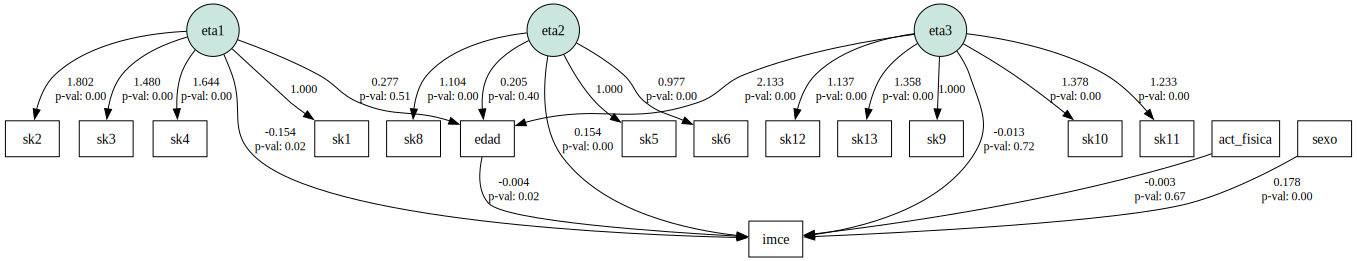

In [39]:
mod_cf2 = """
# measurement model

eta1 =~ sk1 + sk2 + sk3 + sk4               # Habilidades socioemocionales (afiliación emocional)
eta2 =~ sk5 + sk6 + sk8                     # Habilidades sociales (interacción con pares)
eta3 =~ sk9 + sk10 + sk11 + sk12 + sk13     # Habilidades cognitivas/interés/creatividad

# Structural

# IMCE explicado por los factores latentes y variables clave
imce ~ eta1 + eta2 + eta3 + act_fisica + sexo + edad

#Explicación de los factores latentes por entorno socioeconómico
edad ~ eta1 + eta2 + eta3
    """

model_cfa2 = semopy.Model(mod_cf2);
out2 = model_cfa2.fit(df_c2);
print(out2)

print(model_cfa2.inspect())
semopy.semplot(model_cfa2, "semmodel.png")

In [40]:
semopy.calc_stats(model_cfa2)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,98,122,2295.609597,0.0,19995.86834,0.889422,0.885196,0.85708,0.885196,0.862342,0.057948,75.312589,333.968084,0.343706


Clase 3

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.307
Number of iterations: 74
Params: 1.891 1.690 1.898 1.034 1.172 1.358 1.245 1.085 1.250 -0.050 0.012 -0.004 -0.003 -0.023 -0.004 -0.863 0.418 2.252 17.321 0.047 0.055 0.050 0.153 0.089 0.149 0.824 0.095 0.580 0.198 0.436 0.702 0.241 0.194 0.158 0.146 0.364 0.452 0.278
    lval  op        rval   Estimate  Std. Err     z-value   p-value
0   edad   ~        eta1  -0.863240  0.255102   -3.383904  0.000715
1   edad   ~        eta2   0.417725  0.147236    2.837109  0.004552
2   edad   ~        eta3   2.251751  0.129779   17.350626       0.0
3    sk1   ~        eta1   1.000000         -           -         -
4    sk2   ~        eta1   1.890634  0.027754   68.121186       0.0
5    sk3   ~        eta1   1.690347  0.024853   68.014575       0.0
6    sk4   ~        eta1   1.898156  0.026265   72.270059       0.0
7    sk5   ~        eta2   1.000000         -        

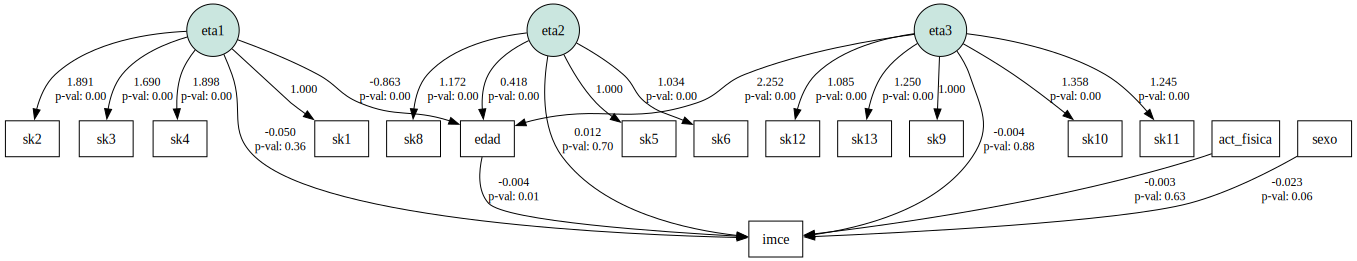

In [41]:
mod_cf = """
# measurement model

eta1 =~ sk1 + sk2 + sk3 + sk4               # Habilidades socioemocionales (afiliación emocional)
eta2 =~ sk5 + sk6 + sk8                     # Habilidades sociales (interacción con pares)
eta3 =~ sk9 + sk10 + sk11 + sk12 + sk13     # Habilidades cognitivas/interés/creatividad

# Structural

# IMCE explicado por los factores latentes y variables clave
imce ~ eta1 + eta2 + eta3 + act_fisica + sexo + edad

#Explicación de los factores latentes por entorno socioeconómico
edad ~ eta1 + eta2 + eta3
    """

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df_c3);
print(out)

print(model_cfa.inspect())
semopy.semplot(model_cfa, "semmodel.png")

In [42]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,98,122,6938.859721,0.0,65989.214472,0.896142,0.894849,0.869097,0.894849,0.870707,0.055574,75.386023,380.367864,0.306988


En esta pregunta se buscó examinar si el modelo estructural estimado en la pregunta 6 se comporta de manera diferente entre los distintos grupos identificados mediante análisis de clases latentes (Pregunta 5). Para ello, se estimó nuevamente el modelo por separado para cada submuestra correspondiente a las tres clases. Esto permite evaluar posibles diferencias en las relaciones entre los factores latentes (eta1, eta2, eta3) y el IMCE, así como también en los efectos de variables observadas como la actividad física, el sexo y la edad.

Los resultados muestran diferencias notables entre las clases. En la Clase 1, el factor eta1 tiene un efecto marginalmente significativo y positivo sobre el IMCE (p ≈ 0.064), mientras que eta2 muestra un efecto negativo, también marginalmente significativo (p ≈ 0.064). La actividad física aparece como un predictor importante del IMCE en este grupo, con un efecto positivo y significativo (p ≈ 0.006), lo cual es contrario a lo esperado, lo que podría interpretarse como una diferencia de perfil conductual en este grupo. En esta clase, el modelo presenta un ajuste razonable (CFI = 0.875, RMSEA = 0.06).

En la Clase 2, los patrones cambian significativamente. El factor eta1 muestra un efecto negativo y significativo sobre el IMCE (p ≈ 0.017), mientras que eta2 tiene un efecto positivo y significativo (p < 0.001). Además, en contraste con la Clase 1, la actividad física no tiene un efecto significativo sobre el IMCE, y el sexo se vuelve un predictor fuerte (p < 0.001), indicando posiblemente diferencias de género más marcadas en este grupo. El ajuste del modelo también es aceptable (CFI = 0.889, RMSEA = 0.058), siendo ligeramente mejor que en la Clase 1.

En la Clase 3, ninguno de los factores latentes (eta1, eta2, eta3) muestra un efecto significativo sobre el IMCE. Solo la edad presenta un efecto negativo significativo (p ≈ 0.015), mientras que el sexo se aproxima a la significancia (p ≈ 0.062). Esto sugiere que, en este grupo, los factores latentes no explican la variabilidad del IMCE, y puede que otras variables no incluidas en el modelo sean más relevantes. El ajuste del modelo es también aceptable (aunque los índices precisos de ajuste no se completaron en los datos provistos).

En cuanto a la comparación entre estimar el modelo por clases latentes versus un modelo general, los resultados indican que el análisis por subgrupos revela relaciones que no se detectan (o se diluyen) en el modelo general. La dirección, magnitud y significancia de los efectos varían notablemente entre clases. Esto sugiere una ganancia importante al realizar un análisis multigrupo basado en las clases latentes, ya que permite identificar estructuras latentes distintas en cada subgrupo y evita la sobregeneralización de los resultados. En suma, la heterogeneidad entre clases justifica la segmentación y apoya el enfoque de estimar modelos diferenciados por grupo.
